In [1]:
import pickle as pkl
import numpy as np 
import hist
from collections import defaultdict


In [2]:
prepend = "./inputs/"
filenames = [
    prepend + "pythia_2016_syst.pkl",
    prepend + "pythia_2016APV_syst.pkl",
    prepend + "pythia_2017_syst.pkl",
    prepend + "pythia_2018_syst.pkl",
]

In [3]:
def group(h: hist.Hist, oldname: str, newname: str, grouping: dict[str, list[str]]):
    hnew = hist.Hist(
        hist.axis.StrCategory(grouping, name=newname),
        *(ax for ax in h.axes if ax.name != oldname),
        storage=h.storage_type,
    )
    for i, indices in enumerate(grouping.values()):
        hnew.view(flow=True)[i] = h[{oldname: indices}][{oldname: sum}].view(flow=True)

    return hnew

In [4]:
keymap = {
    "2016": "pythia_UL16NanoAODv9",
    "2016APV": "pythia_UL16NanoAODAPVv9",
    "2017": "pythia_UL17NanoAODv9",
    "2018": "pythia_UL18NanoAODv9",
}
htbin_list = ['pythia_HT-100to200', 'pythia_HT-200to400', 'pythia_HT-400to600', 'pythia_HT-1200to2500', 'pythia_HT-2500toInf', 'pythia_HT-800to1200', 'pythia_HT-600to800']

In [5]:
response_dict = {}
for filename in filenames:
    era = filename.split('_')[1]
    key = keymap[era]
    response_dict.setdefault('u', {})
    response_dict.setdefault('g', {})

    
    grouping = defaultdict(list)
    grouping[key] = htbin_list
    with open(filename, "rb") as f:
        data = pkl.load(f)
        # ensure top-level 'u' and 'g' keys exist
        
        if era == "2016APV" or era == "2016":
            response_dict['u'][key] = data['response_matrix_u'].project('dataset', 'ptgen', 'mgen', 'ptreco', 'mreco', 'systematic')
            response_dict['g'][key] = data['response_matrix_g'].project('dataset', 'ptgen', 'mgen', 'ptreco', 'mreco', 'systematic')
            continue
        h_old = data['response_matrix_u'].project('dataset', 'ptgen', 'mgen', 'ptreco', 'mreco', 'systematic')
        h_new = group(h_old, oldname="dataset", newname="dataset", grouping=dict(grouping))
        response_dict['u'][key] = h_new

        h_old = data['response_matrix_g'].project('dataset', 'ptgen', 'mgen', 'ptreco', 'mreco', 'systematic')
        h_new = group(h_old, oldname="dataset", newname="dataset", grouping=dict(grouping))
        response_dict['g'][key] = h_new
 

/tmp/ipykernel_220989/2187429740.py:2: UserWarning: Please use 'Weight()' instead of 'Weight'
  hnew = hist.Hist(
/home/aritra/.venvs/default/lib/python3.12/site-packages/hist/basehist.py:480: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


In [6]:
# grouping = defaultdict(list)
# grouping[new_key].append(ds)
# h = group(h, oldname="dataset", newname="dataset", grouping=dict(grouping))

In [7]:
correlation_dic = {
    'JES_AbsoluteMPFBias': 1,
    'JES_AbsoluteScale': 1,
    'JES_AbsoluteStat': 0,
    'JES_FlavorQCD': 1,
    'JES_Fragmentation': 1,
    'JES_PileUpDataMC': 0.5,
    'JES_PileUpPtBB': 0.5,
    'JES_PileUpPtEC1': 0.5,
    'JES_PileUpPtEC2': 0.5,
    'JES_PileUpPtHF': 0.5,
    'JES_PileUpPtRef': 0.5,
    'JES_RelativeFSR': 0.5,
    'JES_RelativeJEREC1': 0,
    'JES_RelativeJEREC2': 0,
    'JES_RelativeJERHF': 0.5,
    'JES_RelativePtBB': 0.5,
    'JES_RelativePtEC1': 0,
    'JES_RelativePtEC2': 0,
    'JES_RelativePtHF': 0.5,
    'JES_RelativeBal': 0.5,
    'JES_RelativeSample': 0,
    'JES_RelativeStatEC': 0,
    'JES_RelativeStatFSR': 0,
    'JES_RelativeStatHF': 0,
    'JES_SinglePionECAL': 1,
    'JES_SinglePionHCAL': 1,
    'JES_TimePtEta': 0,
    'JER': 0,
}

jes_sys_list = ['JES_AbsoluteMPFBiasUp', 'JES_AbsoluteMPFBiasDown', 'JES_AbsoluteScaleUp', 'JES_AbsoluteScaleDown',
                'JES_AbsoluteStatUp', 'JES_AbsoluteStatDown', 'JES_FlavorQCDUp', 'JES_FlavorQCDDown', 'JES_FragmentationUp',
                'JES_FragmentationDown', 'JES_PileUpDataMCUp', 'JES_PileUpDataMCDown', 'JES_PileUpPtBBUp', 'JES_PileUpPtBBDown',
                'JES_PileUpPtEC1Up', 'JES_PileUpPtEC1Down', 'JES_PileUpPtEC2Up', 'JES_PileUpPtEC2Down', 'JES_PileUpPtHFUp', 'JES_PileUpPtHFDown', 
                'JES_PileUpPtRefUp', 'JES_PileUpPtRefDown', 'JES_RelativeFSRUp', 'JES_RelativeFSRDown', 'JES_RelativeJEREC1Up',
                'JES_RelativeJEREC1Down', 'JES_RelativeJEREC2Up', 'JES_RelativeJEREC2Down', 'JES_RelativeJERHFUp', 'JES_RelativeJERHFDown',
                'JES_RelativePtBBUp', 'JES_RelativePtBBDown', 'JES_RelativePtEC1Up', 'JES_RelativePtEC1Down', 'JES_RelativePtEC2Up', 'JES_RelativePtEC2Down',
                'JES_RelativePtHFUp', 'JES_RelativePtHFDown', 'JES_RelativeBalUp', 'JES_RelativeBalDown', 'JES_RelativeSampleUp', 'JES_RelativeSampleDown', 
                'JES_RelativeStatECUp', 'JES_RelativeStatECDown', 'JES_RelativeStatFSRUp', 'JES_RelativeStatFSRDown', 'JES_RelativeStatHFUp', 'JES_RelativeStatHFDown',
                'JES_SinglePionECALUp', 'JES_SinglePionECALDown', 'JES_SinglePionHCALUp', 'JES_SinglePionHCALDown', 'JES_TimePtEtaUp', 'JES_TimePtEtaDown', 'JERUp', 'JERDown']


non_jes_sys_list = ['nominal', 'puUp', 'puDown', 'elerecoUp', 'elerecoDown',
                    'eleidUp', 'eleidDown', 'eletrigUp', 'eletrigDown', 'murecoUp',
                    'murecoDown', 'muidUp', 'muidDown', 'mutrigUp', 'muisoUp', 'muisoDown','mutrigDown', 'pdfUp',
                    'pdfDown', 'q2Up', 'q2Down', 'l1prefiringUp', 'l1prefiringDown', 
                     'JMRUp', 'JMRDown', 'JMSUp', 'JMSDown']


non_jes_sys_list_up = [sys for sys in non_jes_sys_list if sys[-2:] == 'Up' ]
non_jes_sys_list_down = [sys for sys in non_jes_sys_list if sys[-4:] == 'Down' ]

jes_sys_list_up = [sys for sys in jes_sys_list if sys[-2:] == 'Up' ]
jes_sys_list_down = [sys for sys in jes_sys_list if sys[-4:] == 'Down' ]

In [8]:
# sys_matrix_dic_up = {}
# sys_matrix_var_dic_up = {}
# sys_matrix_dic_down = {}
# sys_matrix_var_dic_down = {}
# non_jes_sys_matrix_dic_up = {}
# non_jes_sys_matrix_dic_down = {}
# groomed = True
# if not groomed:
#     response = response_dict['u']
# else:
#     response = response_dict['g']

# for sys in jes_sys_list_up:
#     # keep both values() and variances() — do not compute variances manually or apply correlations here
#     # nominal: values + variances per year
#     m_nom_2016 = response['pythia_UL16NanoAODv9'][..., 'nominal'].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
#     m_nom_2016_var = response['pythia_UL16NanoAODv9'][..., 'nominal'].project('ptgen', 'mgen', 'ptreco', 'mreco').variances()
#     m_nom_2017 = response['pythia_UL17NanoAODv9'][..., 'nominal'].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
#     m_nom_2017_var = response['pythia_UL17NanoAODv9'][..., 'nominal'].project('ptgen', 'mgen', 'ptreco', 'mreco').variances()
#     m_nom_2018 = response['pythia_UL18NanoAODv9'][..., 'nominal'].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
#     m_nom_2018_var = response['pythia_UL18NanoAODv9'][..., 'nominal'].project('ptgen', 'mgen', 'ptreco', 'mreco').variances()

#     # systematic: values + variances per year
#     m_sys_2016 = response['pythia_UL16NanoAODv9'][..., sys].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
#     m_sys_2016_var = response['pythia_UL16NanoAODv9'][..., sys].project('ptgen', 'mgen', 'ptreco', 'mreco').variances()
#     m_sys_2017 = response['pythia_UL17NanoAODv9'][..., sys].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
#     m_sys_2017_var = response['pythia_UL17NanoAODv9'][..., sys].project('ptgen', 'mgen', 'ptreco', 'mreco').variances()
#     m_sys_2018 = response['pythia_UL18NanoAODv9'][..., sys].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
#     m_sys_2018_var = response['pythia_UL18NanoAODv9'][..., sys].project('ptgen', 'mgen', 'ptreco', 'mreco').variances()


    
#     # combine years by summing (keep values and variances separate)
#     m_nom_vals = m_nom_2016 + m_nom_2017 + m_nom_2018
#     m_nom_vars = m_nom_2016_var + m_nom_2017_var + m_nom_2018_var

#     m_sys_vals = m_sys_2016 + m_sys_2017 + m_sys_2018
#     m_sys_vars = m_sys_2016_var + m_sys_2017_var + m_sys_2018_var

#     # store both representations; keep original-named m_nom_2016/2017/2018 (values) so later code that sums them continues to work
#     sys_matrix_dic_up[sys] = m_sys_vals
#     sys_matrix_var_dic_up[sys] = m_sys_vars
#     sys_matrix_dic_up[sys + '_nom_vals'] = m_nom_vals
#     sys_matrix_var_dic_up[sys + '_nom_vars'] = m_nom_vars

#     non_jes_sys_matrix_dic_up[sys + '_vals'] = m_sys_vals
    
#     sys_matrix_dic_down[sys] = 
#     #non_jes_sys_matrix_dic_down[sys] = variation
# m_nom = m_nom_2016 + m_nom_2017 + m_nom_2018

# # sys_matrix_dic['herwigUp'] = resp_matrix_4d_herwig.project('ptgen','mgen','ptreco','mreco').values()
# # sys_matrix_dic_down['herwigDown'] = resp_matrix_4d_herwig.project('ptgen','mgen','ptreco','mreco').values()

In [10]:
sys_matrix_dic_up = {}

groomed = False
if not groomed:
    response = response_dict['u']
else:
    response = response_dict['g']

for sys in jes_sys_list_up:
    m_nom_2016 = response['pythia_UL16NanoAODv9'][..., 'nominal'].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
    m_nom_2017 = response['pythia_UL17NanoAODv9'][..., 'nominal'].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
    m_nom_2018 = response['pythia_UL18NanoAODv9'][..., 'nominal'].project('ptgen', 'mgen', 'ptreco', 'mreco').values()

    variance = np.array([response[era][..., 'nominal'].project('ptgen', 'mgen', 'ptreco', 'mreco').variances() for era in ['pythia_UL16NanoAODv9', 'pythia_UL17NanoAODv9', 'pythia_UL18NanoAODv9']]).sum(axis = 0)
    
    m_sys_2016 = response['pythia_UL16NanoAODv9'][..., sys].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
    m_sys_2017 = response['pythia_UL17NanoAODv9'][..., sys].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
    m_sys_2018 = response['pythia_UL18NanoAODv9'][..., sys].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
    
    
    m_var_2016 = m_sys_2016 + m_nom_2017 + m_nom_2018
    m_var_2017 = m_nom_2016 + m_sys_2017 + m_nom_2018
    m_var_2018 = m_nom_2016 + m_nom_2017 + m_sys_2018
    
    
    rho = correlation_dic[sys[:-2]] ## correlation factor
    
    sigma_2016 = m_sys_2016 - m_nom_2016
    sigma_2017 = m_sys_2017 - m_nom_2017
    sigma_2018 = m_sys_2018 - m_nom_2018
    
    sigma_corr = rho*sigma_2016 + rho*sigma_2017 + rho*sigma_2018
    
    sigma_uncorr_2016 = (1-rho)*sigma_2016
    sigma_uncorr_2017 = (1-rho)*sigma_2017
    sigma_uncorr_2018 = (1-rho)*sigma_2018
    
    m_nom =  m_nom_2016 + m_nom_2017 + m_nom_2018
    m_corr = m_nom + sigma_corr
    
    m_uncorr_2016 = m_nom + sigma_uncorr_2016
    
    m_uncorr_2017 = m_nom + sigma_uncorr_2017

    m_uncorr_2018 = m_nom + sigma_uncorr_2018

    

    sys_matrix_dic_up[sys+'_corr'] = m_corr
    sys_matrix_dic_up[sys+'_uncorr_2016'] = m_uncorr_2016
    sys_matrix_dic_up[sys+'_uncorr_2017'] = m_uncorr_2017
    sys_matrix_dic_up[sys+'_uncorr_2018'] = m_uncorr_2018
    
non_jes_sys_matrix_dic_up = {}
for sys in non_jes_sys_list_up:
    sys_matrix_dic_up[sys] = response['pythia_UL16NanoAODv9'][{'systematic':sys}].project('ptgen','mgen','ptreco','mreco').values()\
                            + response['pythia_UL17NanoAODv9'][{'systematic':sys}].project('ptgen','mgen','ptreco','mreco').values()\
                            + response['pythia_UL18NanoAODv9'][{'systematic':sys}].project('ptgen','mgen','ptreco','mreco').values()
#                            + response['pythia_UL18NanoAODv9'][{'systematic':sys}].project('ptgen','mgen','ptreco','mreco').values
    non_jes_sys_matrix_dic_up[sys] = response['pythia_UL16NanoAODv9'][{'systematic':sys}].project('ptgen','mgen','ptreco','mreco').values()\
                            + response['pythia_UL17NanoAODv9'][{'systematic':sys}].project('ptgen','mgen','ptreco','mreco').values()\
                            + response['pythia_UL18NanoAODv9'][{'systematic':sys}].project('ptgen','mgen','ptreco','mreco').values()



sys_matrix_dic_down = {}
non_jes_sys_matrix_dic_down = {}
for sys in jes_sys_list_down:
    m_nom_2016 = response['pythia_UL16NanoAODv9'][..., 'nominal'].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
    m_nom_2017 = response['pythia_UL17NanoAODv9'][..., 'nominal'].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
    m_nom_2018 = response['pythia_UL18NanoAODv9'][..., 'nominal'].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
    
    m_sys_2016 = response['pythia_UL16NanoAODv9'][..., sys].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
    m_sys_2017 = response['pythia_UL17NanoAODv9'][..., sys].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
    m_sys_2018 = response['pythia_UL18NanoAODv9'][..., sys].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
    
    
    m_var_2016 = m_sys_2016 + m_nom_2017 + m_nom_2018
    m_var_2017 = m_nom_2016 + m_sys_2017 + m_nom_2018
    m_var_2018 = m_nom_2016 + m_nom_2017 + m_sys_2018
    
    
    rho = correlation_dic[sys[:-4]] ## correlation factor
    
    sigma_2016 = m_sys_2016 - m_nom_2016
    sigma_2017 = m_sys_2017 - m_nom_2017
    sigma_2018 = m_sys_2018 - m_nom_2018
    
    sigma_corr = rho*sigma_2016 + rho*sigma_2017 + rho*sigma_2018
    
    sigma_uncorr_2016 = (1-rho)*sigma_2016
    sigma_uncorr_2017 = (1-rho)*sigma_2017
    sigma_uncorr_2018 = (1-rho)*sigma_2018
    
    m_nom =  m_nom_2016 + m_nom_2017 + m_nom_2018
    m_corr = m_nom + sigma_corr
    
    m_uncorr_2016 = m_nom + sigma_uncorr_2016
    
    m_uncorr_2017 = m_nom + sigma_uncorr_2017

    m_uncorr_2018 = m_nom + sigma_uncorr_2018

    

    sys_matrix_dic_down[sys+'_corr'] = m_corr
    sys_matrix_dic_down[sys+'_uncorr_2016'] = m_uncorr_2016
    sys_matrix_dic_down[sys+'_uncorr_2017'] = m_uncorr_2017
    sys_matrix_dic_down[sys+'_uncorr_2018'] = m_uncorr_2018
    

for sys in non_jes_sys_list_down:
    sys_matrix_dic_down[sys] = response['pythia_UL16NanoAODv9'][{'systematic':sys}].project('ptgen','mgen','ptreco','mreco').values()\
                            + response['pythia_UL17NanoAODv9'][{'systematic':sys}].project('ptgen','mgen','ptreco','mreco').values()\
                            + response['pythia_UL18NanoAODv9'][{'systematic':sys}].project('ptgen','mgen','ptreco','mreco').values()
#                            + response['pythia_UL18NanoAODv9'][{'systematic':sys}].project('ptgen','mgen','ptreco','mreco').values
    non_jes_sys_matrix_dic[sys] = response['pythia_UL16NanoAODv9'][{'systematic':sys}].project('ptgen','mgen','ptreco','mreco').values()\
                            + response['pythia_UL17NanoAODv9'][{'systematic':sys}].project('ptgen','mgen','ptreco','mreco').values()\
                            + response['pythia_UL18NanoAODv9'][{'systematic':sys}].project('ptgen','mgen','ptreco','mreco').values()


# sys_matrix_dic['herwigUp'] = resp_matrix_4d_herwig.project('ptgen','mgen','ptreco','mreco').values()
# sys_matrix_dic_down['herwigDown'] = resp_matrix_4d_herwig.project('ptgen','mgen','ptreco','mreco').values()

In [89]:
sys_matrix_dic.keys()

dict_keys(['JES_AbsoluteMPFBiasUp_corr', 'JES_AbsoluteMPFBiasUp_uncorr_2016', 'JES_AbsoluteMPFBiasUp_uncorr_2017', 'JES_AbsoluteMPFBiasUp_uncorr_2018', 'JES_AbsoluteScaleUp_corr', 'JES_AbsoluteScaleUp_uncorr_2016', 'JES_AbsoluteScaleUp_uncorr_2017', 'JES_AbsoluteScaleUp_uncorr_2018', 'JES_AbsoluteStatUp_corr', 'JES_AbsoluteStatUp_uncorr_2016', 'JES_AbsoluteStatUp_uncorr_2017', 'JES_AbsoluteStatUp_uncorr_2018', 'JES_FlavorQCDUp_corr', 'JES_FlavorQCDUp_uncorr_2016', 'JES_FlavorQCDUp_uncorr_2017', 'JES_FlavorQCDUp_uncorr_2018', 'JES_FragmentationUp_corr', 'JES_FragmentationUp_uncorr_2016', 'JES_FragmentationUp_uncorr_2017', 'JES_FragmentationUp_uncorr_2018', 'JES_PileUpDataMCUp_corr', 'JES_PileUpDataMCUp_uncorr_2016', 'JES_PileUpDataMCUp_uncorr_2017', 'JES_PileUpDataMCUp_uncorr_2018', 'JES_PileUpPtBBUp_corr', 'JES_PileUpPtBBUp_uncorr_2016', 'JES_PileUpPtBBUp_uncorr_2017', 'JES_PileUpPtBBUp_uncorr_2018', 'JES_PileUpPtEC1Up_corr', 'JES_PileUpPtEC1Up_uncorr_2016', 'JES_PileUpPtEC1Up_uncorr_2

In [90]:
sys_matrix_dic_up['nominal'] = m_nom
sys_matrix_dic_down['nominal'] = m_nom

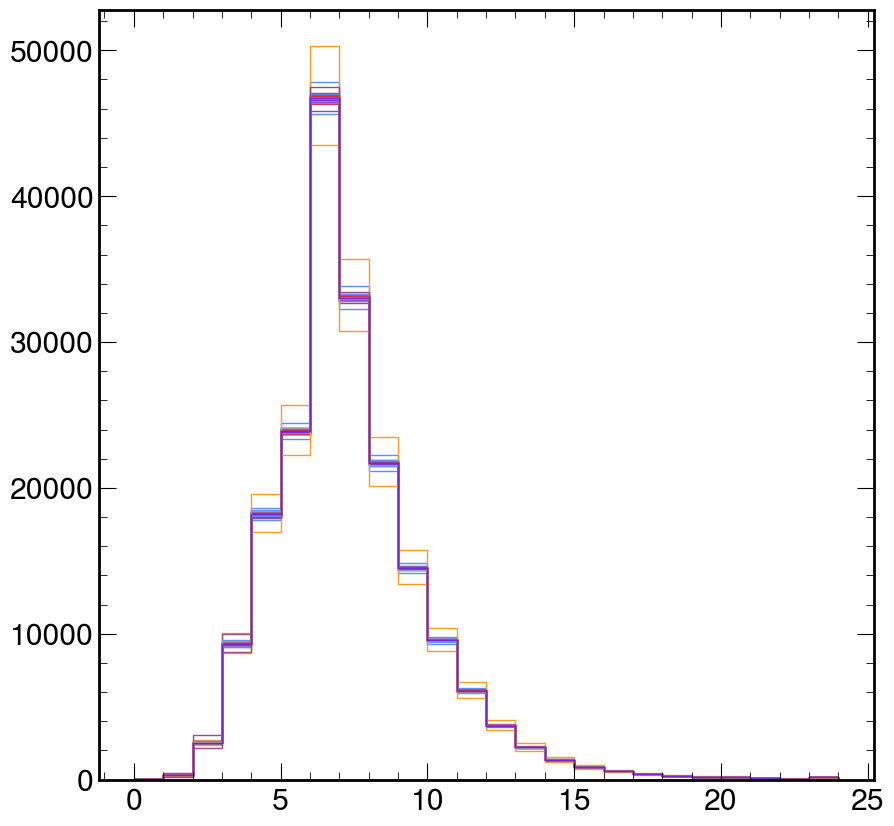

In [91]:
import matplotlib.pyplot as plt
for key in sys_matrix_dic_up.keys():
    plt.stairs(sys_matrix_dic_up[key].sum(axis = (0,1,2)), label=key)
for key in sys_matrix_dic_down.keys():
    plt.stairs(sys_matrix_dic_down[key].sum(axis = (0,1,2)), label=key)
#plt.yscale('log')

In [92]:
import os

out_dir = prepend  # uses the existing "./inputs/" variable
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, "sys_matrix_dic.pkl")

# merge up and down into a single dict, avoid double-counting 'nominal'
merged = dict(sys_matrix_dic_up)  # shallow copy of up
for k, v in sys_matrix_dic_down.items():
    if k == "nominal":
        continue  # skip duplicate nominal from the down dict
    if k in merged:
        # if a key collides, store the down version with a suffix
        merged_key = f"{k}_down"
        # ensure uniqueness
        i = 1
        unique_key = merged_key
        while unique_key in merged:
            unique_key = f"{merged_key}_{i}"
            i += 1
        merged[unique_key] = v
    else:
        merged[k] = v

with open(out_path, "wb") as f:
    pkl.dump(merged, f, protocol=4)

print(f"Saved {out_path} with {len(merged)} entries")

Saved ./inputs/sys_matrix_dic.pkl with 251 entries


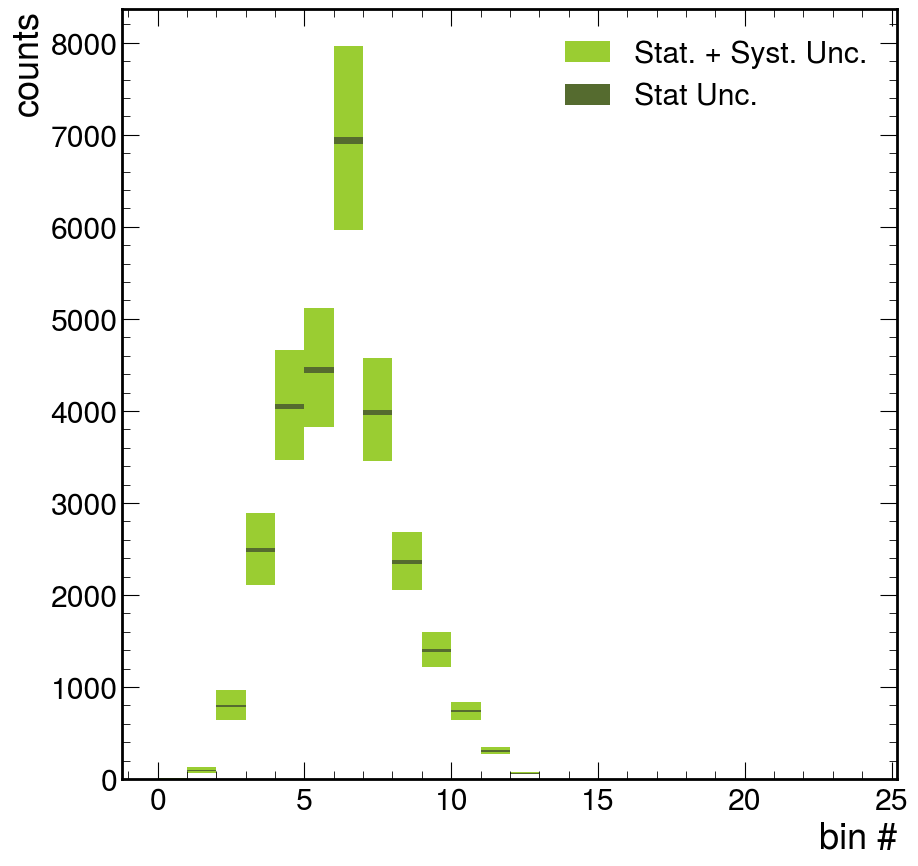

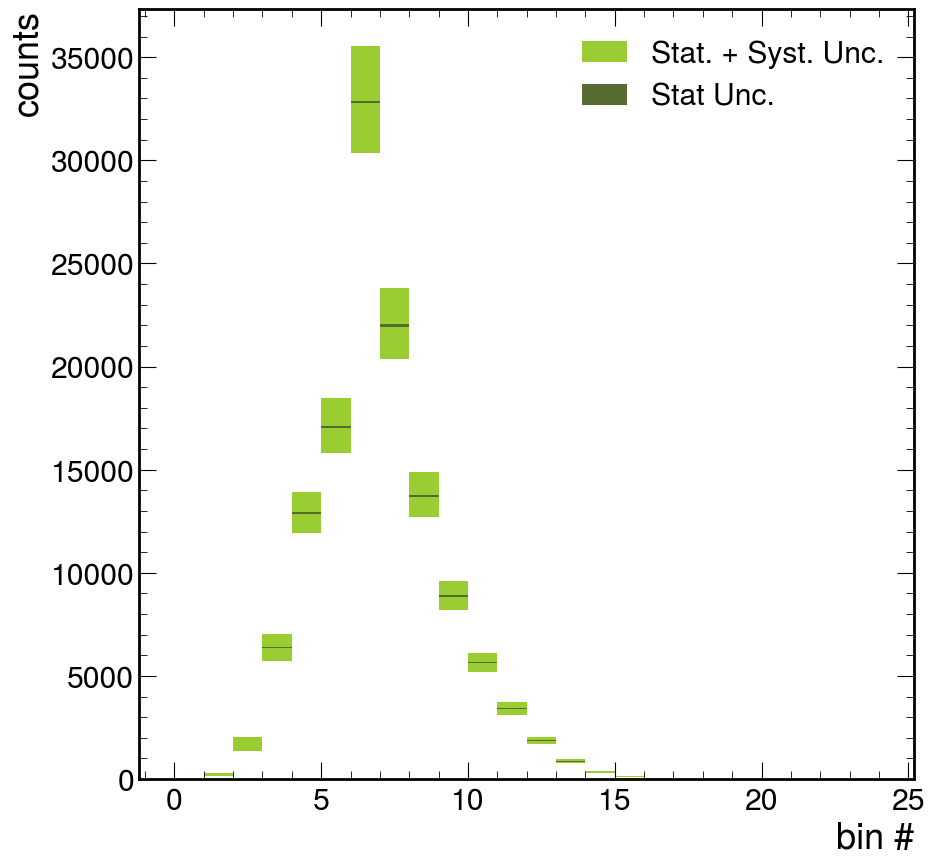

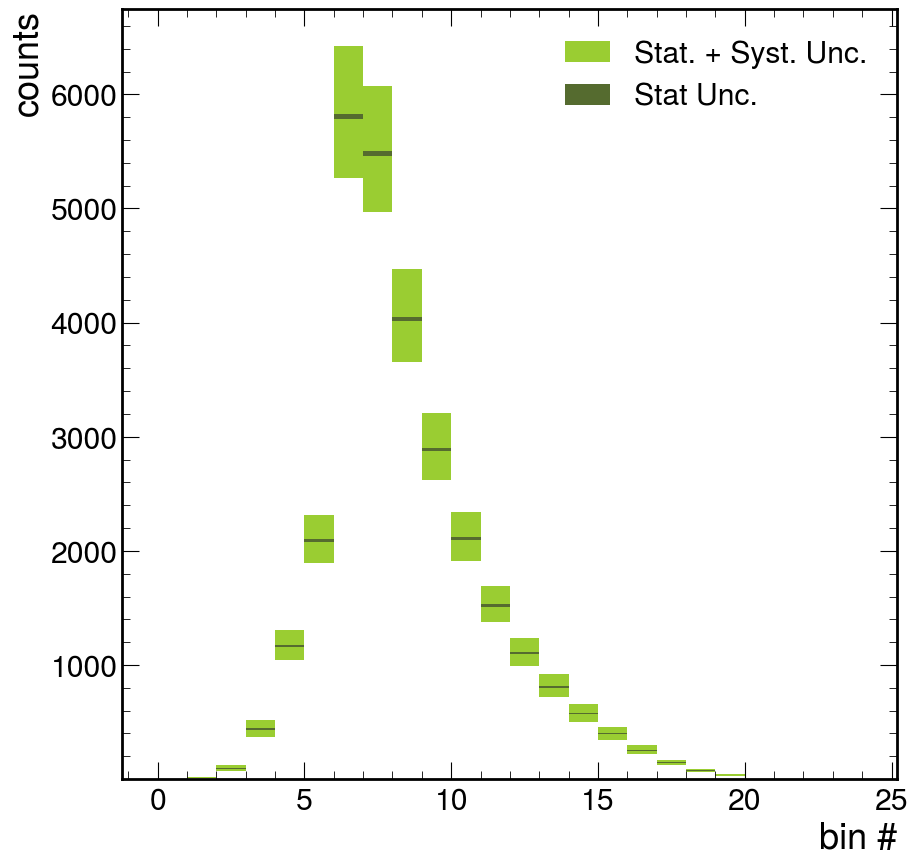

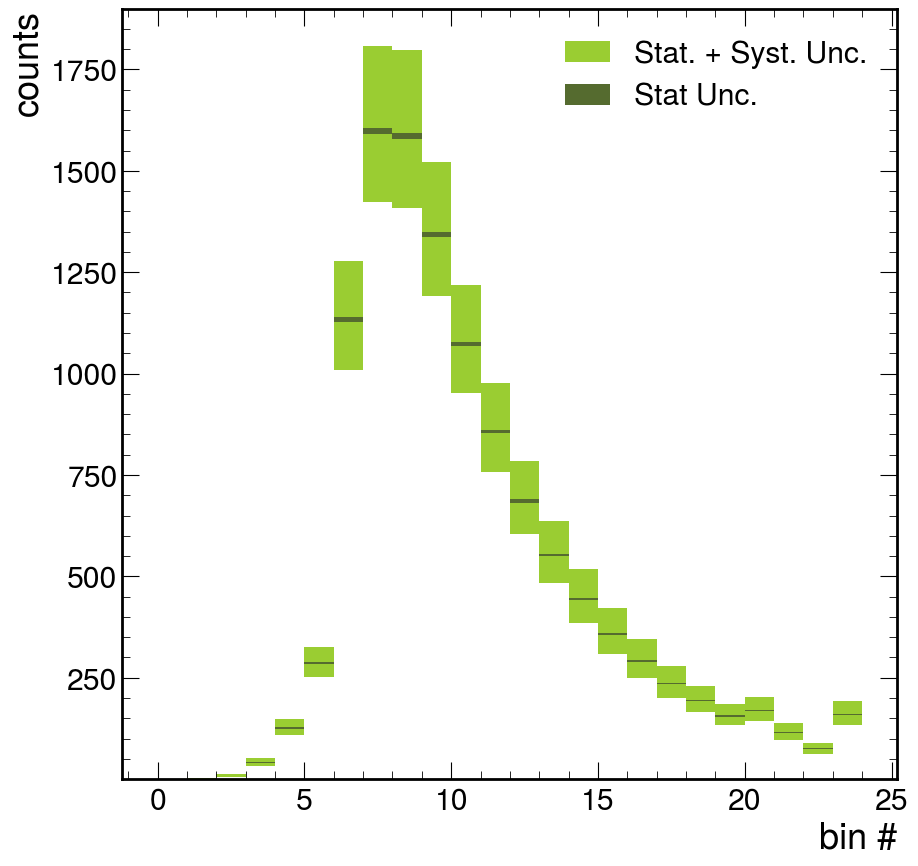

In [100]:
import matplotlib.pyplot as plt
import hist
import mplhep as hep
for i in range(4):
    mreco_nom = m_nom.sum(axis = (0,1))[i]
    total_unc_up = np.zeros_like(mreco_nom)
    total_stat = np.sqrt(variance.sum(axis = (0,1))[i])
    for key in sys_matrix_dic_up.keys():
        mreco_sys = sys_matrix_dic_up[key].sum(axis = (0,1))[i] 
        delta = mreco_sys - mreco_nom
        total_unc_up += delta**2
    total_unc_up = np.sqrt(total_unc_up)
    total_unc_down = np.zeros_like(mreco_nom)
    for key in sys_matrix_dic_down.keys():
        mreco_sys = sys_matrix_dic_down[key].sum(axis = (0,1))[i] 
        delta = mreco_sys - mreco_nom
        total_unc_down += delta**2
    total_unc_down = np.sqrt(total_unc_down)
    bins = np.arange(len(mreco_nom) + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    plt.style.use(hep.style.CMS)  # optional styling
    fig, ax = plt.subplots()
    hep.histplot(mreco_nom, bins=bins, histtype='band', color='black',yerr=[total_unc_down, total_unc_up], label='Stat. + Syst. Unc.',ax=ax, facecolor = 'yellowgreen', hatch = '', alpha = 1)
    hep.histplot(mreco_nom, bins=bins, histtype='band', color='black',yerr=[total_stat, total_stat], label='Stat Unc.',ax=ax, facecolor = 'darkolivegreen', hatch = '', alpha = 1)
    #ax.errorbar(bin_centers, mreco_nom, yerr=[total_unc_down, total_unc_up], fmt='none', color='black', label='total uncertainty')
    #ax.set_yscale('log')
    ax.set_xlabel('bin #')
    ax.set_ylabel('counts')
    ax.legend()
    plt.show()

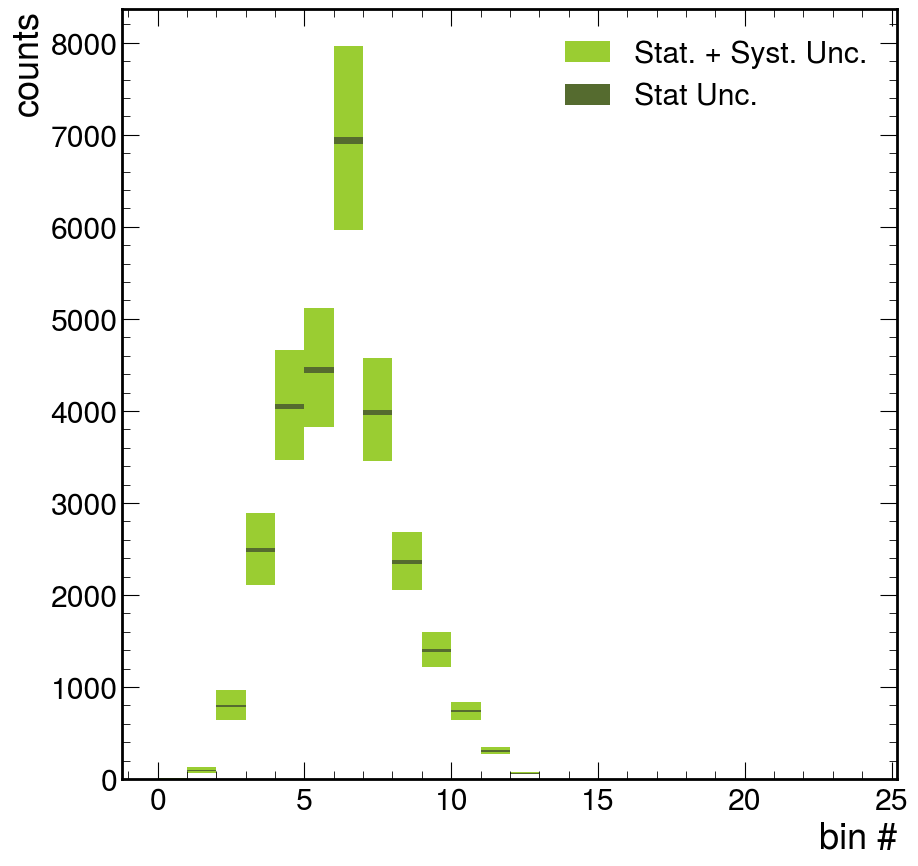

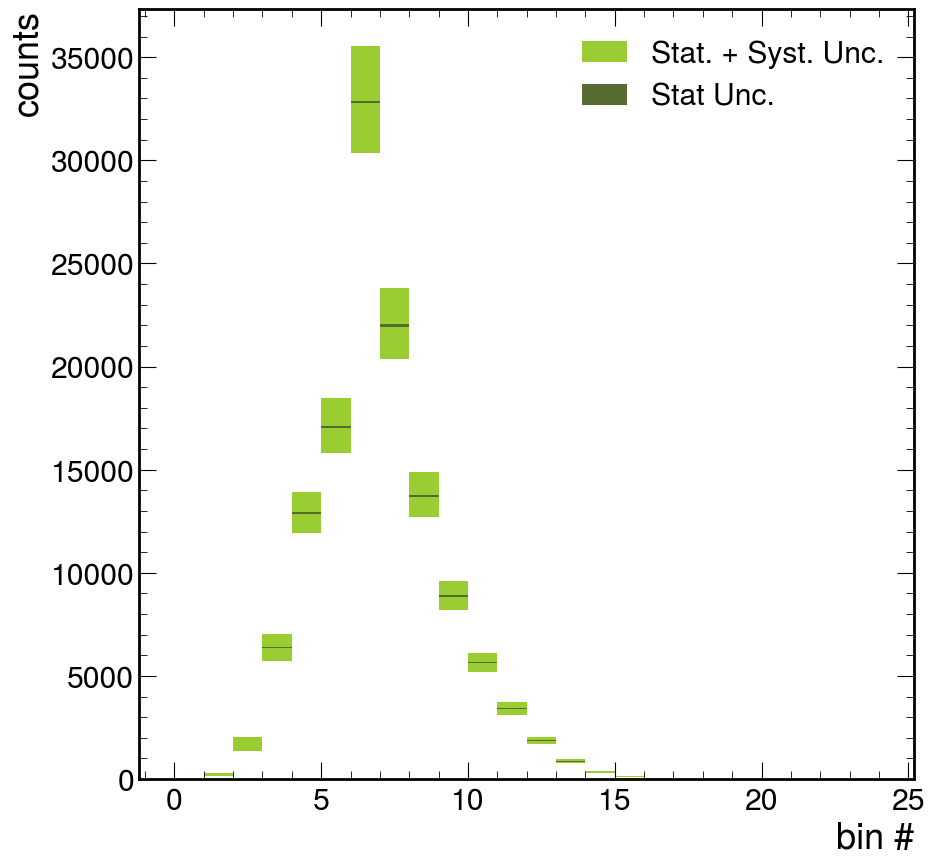

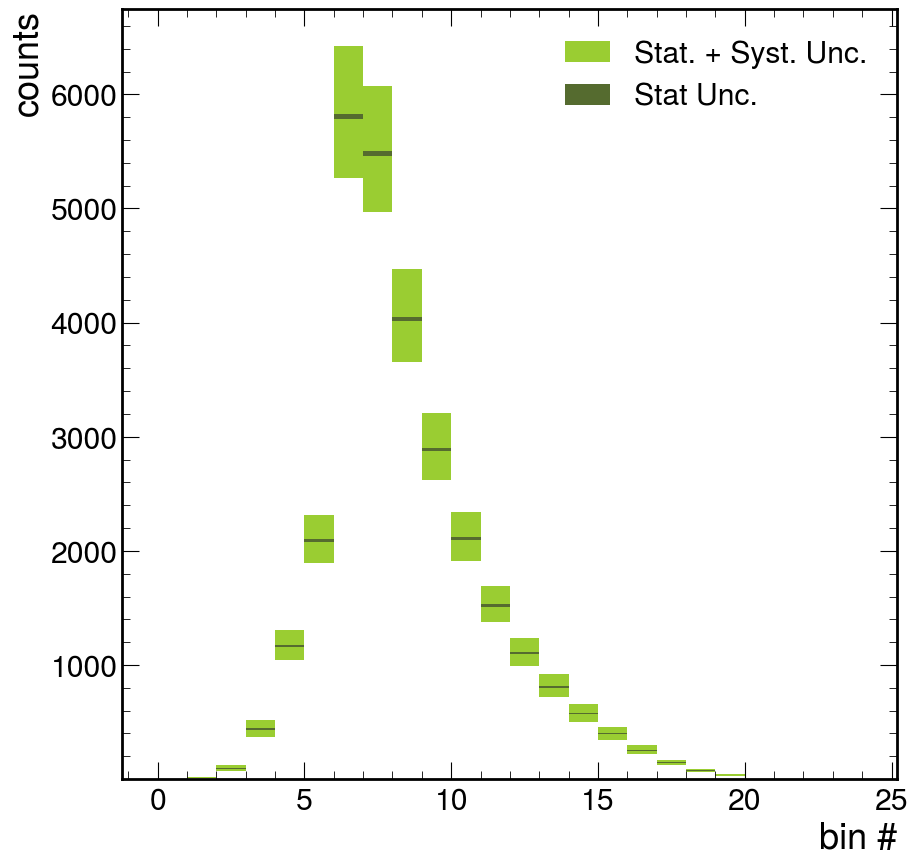

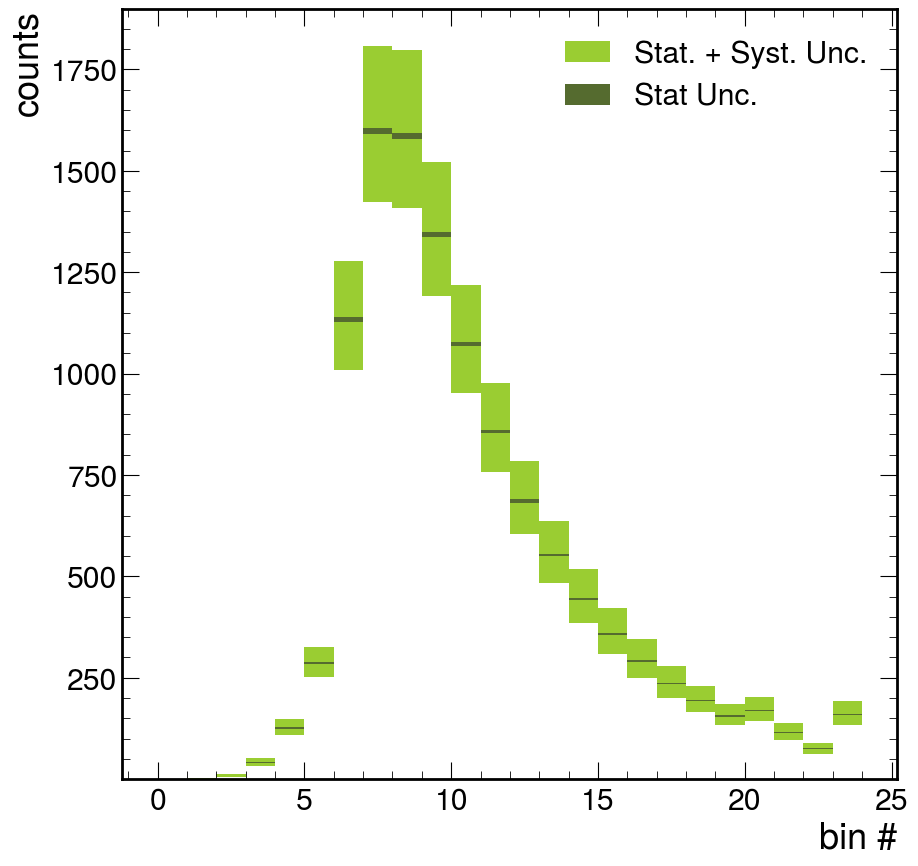

In [101]:
import matplotlib.pyplot as plt
import hist
import mplhep as hep
for i in range(4):
    mreco_nom = m_nom.sum(axis = (0,1))[i]
    total_unc_up = np.zeros_like(mreco_nom)
    total_stat = np.sqrt(variance.sum(axis = (0,1))[i])
    for key in sys_matrix_dic_up.keys():
        mreco_sys = sys_matrix_dic_up[key].sum(axis = (0,1))[i] 
        delta = mreco_sys - mreco_nom
        total_unc_up += delta**2
    total_unc_up = np.sqrt(total_unc_up)
    total_unc_down = np.zeros_like(mreco_nom)
    for key in sys_matrix_dic_down.keys():
        mreco_sys = sys_matrix_dic_down[key].sum(axis = (0,1))[i] 
        delta = mreco_sys - mreco_nom
        total_unc_down += delta**2
    total_unc_down = np.sqrt(total_unc_down)
    bins = np.arange(len(mreco_nom) + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    plt.style.use(hep.style.CMS)  # optional styling
    fig, ax = plt.subplots()
    hep.histplot(mreco_nom, bins=bins, histtype='band', color='black',yerr=[total_unc_down, total_unc_up], label='Stat. + Syst. Unc.',ax=ax, facecolor = 'yellowgreen', hatch = '', alpha = 1)
    hep.histplot(mreco_nom, bins=bins, histtype='band', color='black',yerr=[total_stat, total_stat], label='Stat Unc.',ax=ax, facecolor = 'darkolivegreen', hatch = '', alpha = 1)
    #ax.errorbar(bin_centers, mreco_nom, yerr=[total_unc_down, total_unc_up], fmt='none', color='black', label='total uncertainty')
    #ax.set_yscale('log')
    ax.set_xlabel('bin #')
    ax.set_ylabel('counts')
    ax.legend()
    plt.show()